In [15]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import yfinance as yf
import pandas as pd
import numpy as np
import arch
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')



In [3]:
# configurations and data loading
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'WMT']
benchmark = 'SPY'
start_date = '2019-01-01'
end_date = '2024-12-31'
data = yf.download(
    tickers + [benchmark],
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust=True          # gives a single 'Close' column already adjusted
)

# yfinance returns a multi-level column DataFrame. Extract 'Close'.
prices = data['Close'].copy()

# Drop rows with any missing values (holidays, etc.)
prices.dropna(inplace=True)

# --- Quick sanity check ---
print(prices.head())
print(f"\nShape: {prices.shape} (days x assets)")

Ticker           AAPL         JNJ        JPM         SPY        WMT        XOM
2019-01-02  37.469212  103.790985  80.836525  224.382568  27.913776  49.664749
2019-01-03  33.736992  102.141716  79.687691  219.028091  27.770229  48.902206
2019-01-04  35.177204  103.855972  82.625389  226.364655  27.943684  50.705219
2019-01-07  35.098907  103.189766  82.682846  228.149490  28.272646  50.968891
2019-01-08  35.767998  105.586517  82.526917  230.293015  28.470013  51.339474

Shape: (1509, 6) (days x assets)


In [4]:
returns = prices.pct_change().dropna()
print(returns.head())

Ticker          AAPL       JNJ       JPM       SPY       WMT       XOM
2019-01-03 -0.099608 -0.015890 -0.014212 -0.023863 -0.005143 -0.015354
2019-01-04  0.042689  0.016783  0.036865  0.033496  0.006246  0.036870
2019-01-07 -0.002226 -0.006415  0.000695  0.007885  0.011772  0.005200
2019-01-08  0.019063  0.023227 -0.001886  0.009395  0.006981  0.007271
2019-01-09  0.016982 -0.007926 -0.001690  0.004674 -0.003256  0.005275


In [5]:
cum_returns = (1 + returns).cumprod()

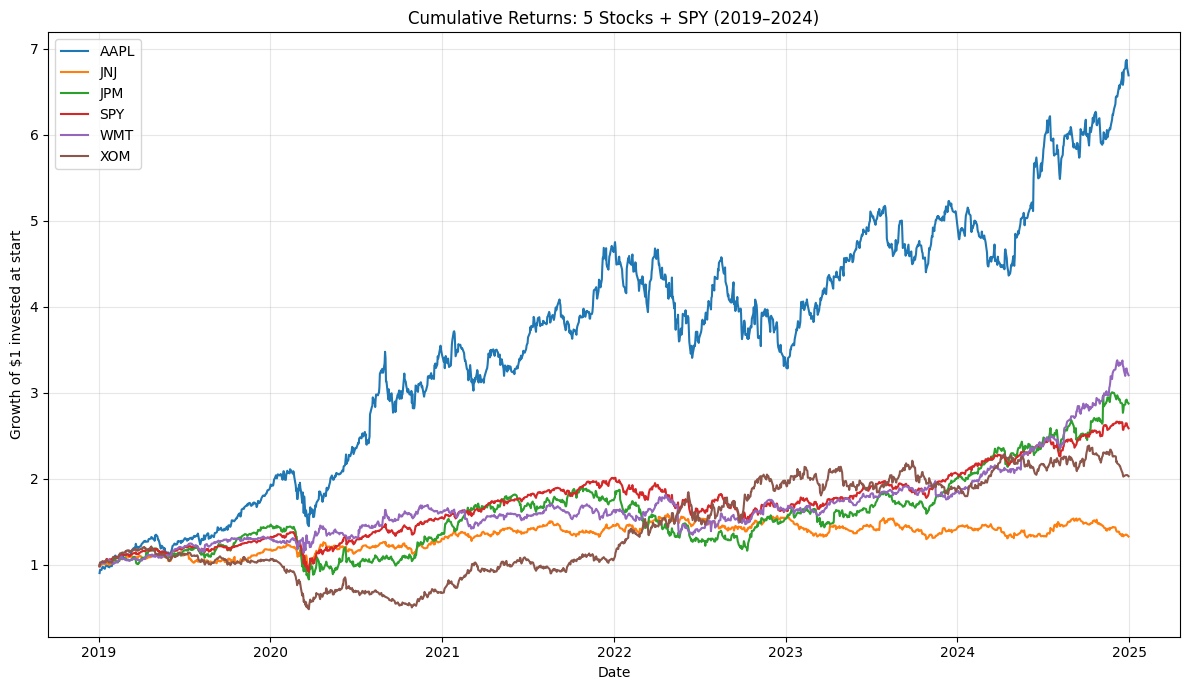

In [6]:
plt.figure(figsize=(12, 7))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)

plt.title('Cumulative Returns: 5 Stocks + SPY (2019–2024)')
plt.ylabel('Growth of $1 invested at start')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
def annualized_volatility(series):
    return series.std() * np.sqrt(252)
def max_drawdown(series):
    """From daily returns, return maximum drawdown as a negative decimal"""
    cum_price = (1 + series).cumprod()
    running_max = cum_price.cummax()
    dd = (cum_price - running_max) / running_max
    return dd.min()

results = []

# Prepare subplots for histograms (2 rows, 3 columns → we use 5)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ret = returns[ticker].dropna()
    mu = ret.mean()
    sigma = ret.std()
    
    # Basic statistics
    ann_vol = annualized_volatility(ret)
    skew = stats.skew(ret)
    kurt = stats.kurtosis(ret)          # excess kurtosis (normal = 0)
    
    # 95% Historical VaR & CVaR
    var_95 = np.percentile(ret, 5)
    cvar_95 = ret[ret <= var_95].mean()
    
    # 95% Parametric VaR (normal distribution)
    z = stats.norm.ppf(0.05)            # ≈ -1.645
    var_normal = mu + z * sigma
    
    # Cornish-Fisher VaR & CVaR
    # Adjusted z-score
    z_cf = (z
            + (1/6) * (z**2 - 1) * skew
            + (1/24) * (z**3 - 3*z) * kurt
            - (1/36) * (2*z**3 - 5*z) * (skew**2))
    var_cf = mu + z_cf * sigma
    
    # CVaR approximation (Cornish-Fisher)
    pdf_z = stats.norm.pdf(z)
    cvar_cf = mu + sigma * (pdf_z / 0.05) * (
        1
        + (1/6) * z * skew
        + (1/24) * (z**2 - 1) * kurt
        + (1/36) * (2*z**3 - 5*z) * (skew**2)
    )
    
    # Maximum drawdown
    dd = max_drawdown(ret)
    
    # Store results
    results.append({
        'ticker': ticker,
        'ann_vol': round(ann_vol, 4),
        'skewness': round(skew, 3),
        'ex_kurtosis': round(kurt, 3),
        'var_hist_95': round(var_95, 4),
        'cvar_hist_95': round(cvar_95, 4),
        'var_normal_95': round(var_normal, 4),
        'var_cf_95': round(var_cf, 4),
        'cvar_cf_95': round(cvar_cf, 4),
        'max_drawdown': round(dd, 4)
    })
    
    # Histogram with normal overlay
    ax = axes[i]
    ax.hist(ret, bins=60, density=True, alpha=0.6, color='steelblue', label='Daily returns')
    x_vals = np.linspace(ret.min(), ret.max(), 200)
    ax.plot(x_vals, stats.norm.pdf(x_vals, mu, sigma), 'r-', lw=2, label='Normal fit')
    ax.axvline(var_95, color='darkred', linestyle='--', label=f'Hist VaR {var_95:.4f}')
    ax.set_title(ticker)
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[-1].axis('off')

plt.suptitle('Histograms of Daily Returns with Normal Fit', fontsize=14)
plt.tight_layout()
plt.savefig('phase1_histograms.png')
plt.close()

# ------------------------------------------------------------
# 3. Summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame(results).set_index('ticker')
print("\n========== UNIVARIATE RISK METRICS (Phase 1) ==========")
print(summary_df.to_string())

# Save to CSV
summary_df.to_csv('phase1_summary.csv')
print("\nTable saved to phase1_summary.csv, histograms saved to phase1_histograms.png")


========== UNIVARIATE RISK METRICS (Phase 1) ==========
        ann_vol  skewness  ex_kurtosis  var_hist_95  cvar_hist_95  var_normal_95  var_cf_95  cvar_cf_95  max_drawdown
ticker                                                                                                               
AAPL     0.3085    -0.010        5.486      -0.0295       -0.0437        -0.0305    -0.0284      0.0573       -0.3143
JPM      0.3066     0.439       13.871      -0.0275       -0.0428        -0.0309    -0.0230      0.0751       -0.4363
XOM      0.3226     0.060        5.181      -0.0301       -0.0453        -0.0327    -0.0303      0.0573       -0.6035
JNJ      0.1915     0.252        8.238      -0.0165       -0.0274        -0.0196    -0.0167      0.0380       -0.2737
WMT      0.2143     0.099       14.814      -0.0181       -0.0291        -0.0213    -0.0169      0.0573       -0.2574

Table saved to phase1_summary.csv, histograms saved to phase1_histograms.png


In [8]:
# Use AAPL returns (percentage form or decimal – both work)
ret = returns['AAPL'].dropna()

# ACF of returns
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(ret, lags=40, ax=ax[0])
ax[0].set_title('ACF of AAPL Returns')
plot_acf(ret**2, lags=40, ax=ax[1])
ax[1].set_title('ACF of AAPL Squared Returns')
plt.tight_layout()
plt.savefig('phase2_acf_diagnostics.png')
plt.close()

# Ljung-Box test on squared returns (10 lags)
lb = acorr_ljungbox(ret**2, lags=[10, 20, 30], return_df=True)
print(lb)

       lb_stat      lb_pvalue
10  688.488207  1.857809e-141
20  848.506161  7.036873e-167
30  890.299677  6.705108e-168


In [9]:
"""
Phase 2 – Volatility Dynamics & GARCH
---------------------------------------
Plots rolling volatility, fits a GARCH(1,1) model,
compares fitted conditional volatility with rolling vol,
and forecasts volatility 5 days ahead.
"""

# ------------------------------------------------------------
# 0. Make sure we have returns (run Phase 0 if needed)
# ------------------------------------------------------------
# If you already have `returns` from Phase 0/1, skip this block.
# Otherwise uncomment the download:
# import yfinance as yf
# tickers = ['AAPL','JPM','XOM','JNJ','WMT','SPY']
# data = yf.download(tickers, start='2019-01-01', end='2024-12-31',
#                    progress=False, auto_adjust=True)
# prices = data['Close'].dropna()
# returns = prices.pct_change().dropna()

# Pick the stock to analyze
ticker = 'AAPL'
ret = returns[ticker].dropna() * 100   # scale to percentage for GARCH stability

# ------------------------------------------------------------
# 1. Rolling (historical) volatility – 21 trading days
# ------------------------------------------------------------
rolling_vol = ret.rolling(21).std() * np.sqrt(252) / 100
# Note: we scaled ret to %, so std is in %; we convert back to decimal annualized

# Plot rolling volatility
plt.figure(figsize=(10, 5))
plt.plot(rolling_vol, label='Rolling 21‑day Annualized Vol', color='steelblue')
plt.title(f'{ticker} Rolling Historical Volatility')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase2_rolling_vol.png')
plt.close()
print("Rolling volatility plot saved: phase2_rolling_vol.png")

# ------------------------------------------------------------
# 2. Fit GARCH(1,1) on daily percentage returns
# ------------------------------------------------------------
model = arch.arch_model(ret, vol='Garch', p=1, q=1, dist='normal')
fitted = model.fit(disp='off')          # disp='off' hides fitting progress
print(f"\nGARCH(1,1) results for {ticker}:")
print(fitted.summary())

# Extract fitted conditional volatility (daily %, convert to annualized)
cond_vol_daily_pct = fitted.conditional_volatility      # in % (same scale as ret)
cond_vol_annual = cond_vol_daily_pct * np.sqrt(252) / 100  # decimal annualized

# ------------------------------------------------------------
# 3. Compare conditional GARCH vol with rolling vol
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(rolling_vol, label='Rolling 21‑day Vol', color='steelblue', alpha=0.7)
plt.plot(cond_vol_annual, label='GARCH Conditional Vol (annualized)', color='darkred')
plt.title(f'{ticker}: Rolling Vol vs GARCH Conditional Vol')
plt.ylabel('Annualized Volatility')
plt.xlabel('Date')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase2_garch_vs_rolling.png')
plt.close()
print("Comparison plot saved: phase2_garch_vs_rolling.png")

# ------------------------------------------------------------
# 4. Forecast volatility 5 trading days ahead
# ------------------------------------------------------------
forecast_horizon = 5
forecast = fitted.forecast(horizon=forecast_horizon)
# forecast.variance is a DataFrame: rows = observation index, columns = step ahead
# Last row contains the forecast from the most recent date
variance_forecast = forecast.variance.values[-1, :]   # array of 5 forecasts
vol_forecast_daily_pct = np.sqrt(variance_forecast)
vol_forecast_annual = vol_forecast_daily_pct * np.sqrt(252) / 100

print(f"\nForecasted annualized volatility for next {forecast_horizon} days:")
for i, vol in enumerate(vol_forecast_annual, 1):
    print(f"  Day +{i}: {vol:.4f}")

# Plot forecast
plt.figure(figsize=(8, 4))
plt.plot(range(1, forecast_horizon+1), vol_forecast_annual, 'o-', color='darkred')
plt.title(f'{ticker} GARCH Volatility Forecast (next {forecast_horizon} days)')
plt.ylabel('Annualized Volatility')
plt.xlabel('Days Ahead')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase2_forecast.png')
plt.close()
print("Forecast plot saved: phase2_forecast.png")

Rolling volatility plot saved: phase2_rolling_vol.png

GARCH(1,1) results for AAPL:
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2974.84
Distribution:                  Normal   AIC:                           5957.68
Method:            Maximum Likelihood   BIC:                           5978.95
                                        No. Observations:                 1508
Date:                Sun, May 31 2026   Df Residuals:                     1507
Time:                        20:37:43   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
-----------------------------------------------------------

In [10]:
"""
Phase 3 – VaR Backtesting
--------------------------
Tests whether the 95% Historical VaR and 95% Parametric (Normal) VaR
accurately predict tail risk. Uses a rolling 500‑day window, counts
violations, and performs the Kupiec (1995) unconditional coverage test.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

# ============================================================
# 0. Load or ensure we have returns (run Phase 0 if needed)
# ============================================================
# Assuming `returns` is a DataFrame with columns ['AAPL','JPM','XOM','JNJ','WMT','SPY']
# If not, uncomment and run Phase 0 first:
# import yfinance as yf
# tickers = ['AAPL','JPM','XOM','JNJ','WMT','SPY']
# data = yf.download(tickers, start='2019-01-01', end='2024-12-31',
#                    progress=False, auto_adjust=True)
# prices = data['Close'].dropna()
# returns = prices.pct_change().dropna()

ticker = 'AAPL'
ret = returns[ticker].dropna()

# ============================================================
# 1. Parameters
# ============================================================
window = 500            # rolling window length
confidence = 0.95       # VaR confidence level
var_percentile = 100 * (1 - confidence)   # 5 for 95% VaR

# ============================================================
# 2. Rolling VaR computation
# ============================================================
# We'll loop day-by-day, expanding the window.
# For each day (starting from day 'window'), we look at the previous 500 returns,
# compute VaR, then compare with the actual next-day return.

actual_returns = []        # actual return on day t+1
var_hist_series = []       # historical VaR estimate for day t+1
var_norm_series = []       # parametric VaR estimate for day t+1

for t in range(window, len(ret) - 1):   # stop at len-1 because we need t+1
    # Past 500 days up to yesterday (t-1)
    past = ret.iloc[t - window : t]
    
    # Historical VaR: 5th percentile
    var_hist = np.percentile(past, var_percentile)
    
    # Normal VaR: mean + z * std
    mu = past.mean()
    sigma = past.std()
    z = norm.ppf(1 - confidence)
    var_norm = mu + z * sigma
    
    # Actual next-day return
    actual = ret.iloc[t]   # return on day t (the "today" after the window)
    
    # Store
    actual_returns.append(actual)
    var_hist_series.append(var_hist)
    var_norm_series.append(var_norm)

# Convert to arrays for convenience
actual_returns = np.array(actual_returns)
var_hist_series = np.array(var_hist_series)
var_norm_series = np.array(var_norm_series)

# ============================================================
# 3. Violations
# ============================================================
violations_hist = actual_returns < var_hist_series
violations_norm = actual_returns < var_norm_series

n_obs = len(actual_returns)
viol_hist_count = violations_hist.sum()
viol_norm_count = violations_norm.sum()

viol_hist_rate = viol_hist_count / n_obs
viol_norm_rate = viol_norm_count / n_obs

print(f"\nBacktesting {ticker} 95% VaR (rolling {window}-day window)")
print(f"Number of observations: {n_obs}")
print(f"Expected violation rate: {1 - confidence:.2%}")
print(f"\nHistorical VaR:")
print(f"  Violations: {viol_hist_count} ({viol_hist_rate:.2%})")
print(f"\nParametric VaR:")
print(f"  Violations: {viol_norm_count} ({viol_norm_rate:.2%})")

# ============================================================
# 4. Kupiec Test (Unconditional Coverage)
# ============================================================
def kupiec_test(violations, conf_level=0.95):
    """
    Kupiec (1995) test for unconditional coverage.
    H0: violation rate = 1 - conf_level
    Returns test statistic and p-value.
    """
    n = len(violations)
    x = violations.sum()
    p_expected = 1 - conf_level
    p_observed = x / n
    
    # Log-likelihood under H0
    ll_H0 = x * np.log(p_expected) + (n - x) * np.log(1 - p_expected)
    # Log-likelihood unrestricted (MLE)
    ll_H1 = x * np.log(p_observed) + (n - x) * np.log(1 - p_observed) if x not in [0, n] else ll_H0
    # Likelihood ratio statistic
    LR = -2 * (ll_H0 - ll_H1)
    p_value = 1 - norm.cdf(np.sqrt(LR))  # chi-squared with 1 df, but we use asymptotic normal for simplicity
    # Actually LR_stat ~ chi2(1); but here we use sqrt(LR) as z-score for normal approximation? Better use chi2.
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(LR, df=1)
    return LR, p_value

lr_hist, p_hist = kupiec_test(violations_hist, confidence)
lr_norm, p_norm = kupiec_test(violations_norm, confidence)

print(f"\nKupiec Test Results:")
print(f"  Historical VaR: LR stat = {lr_hist:.3f}, p-value = {p_hist:.3f}")
print(f"  Normal VaR:     LR stat = {lr_norm:.3f}, p-value = {p_norm:.3f}")
print("  (If p < 0.05, reject the model at 5% significance)")

# ============================================================
# 5. Plot violations
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

dates = ret.index[window : len(ret) - 1]

# Historical VaR
ax1.plot(dates, actual_returns, alpha=0.4, label='Actual returns', color='gray')
ax1.plot(dates, var_hist_series, 'r-', lw=1, label='Historical VaR 95%')
ax1.scatter(dates[violations_hist], actual_returns[violations_hist],
            color='darkred', s=10, alpha=0.8, label=f'Violations ({viol_hist_rate:.1%})')
ax1.set_title(f'{ticker} - Historical VaR 95% Backtest (rolling {window}-day)')
ax1.legend()
ax1.grid(alpha=0.3)

# Normal VaR
ax2.plot(dates, actual_returns, alpha=0.4, label='Actual returns', color='gray')
ax2.plot(dates, var_norm_series, 'b-', lw=1, label='Normal VaR 95%')
ax2.scatter(dates[violations_norm], actual_returns[violations_norm],
            color='darkblue', s=10, alpha=0.8, label=f'Violations ({viol_norm_rate:.1%})')
ax2.set_title(f'{ticker} - Normal VaR 95% Backtest (rolling {window}-day)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_backtest.png')
plt.close()
print("\nBacktest plot saved: phase3_backtest.png")


Backtesting AAPL 95% VaR (rolling 500-day window)
Number of observations: 1007
Expected violation rate: 5.00%

Historical VaR:
  Violations: 41 (4.07%)

Parametric VaR:
  Violations: 36 (3.57%)

Kupiec Test Results:
  Historical VaR: LR stat = 1.946, p-value = 0.163
  Normal VaR:     LR stat = 4.760, p-value = 0.029
  (If p < 0.05, reject the model at 5% significance)

Backtest plot saved: phase3_backtest.png


In [11]:
"""
Phase 4 – Dependence & Portfolio Risk
--------------------------------------
Computes the correlation matrix of daily returns, builds an equal‑weighted
portfolio, calculates portfolio volatility and VaR, and measures the
diversification benefit.
"""
# ============================================================
# 0. Make sure we have returns (run Phase 0 if needed)
# ============================================================
# `returns` should be a DataFrame with columns:
# ['AAPL','JPM','XOM','JNJ','WMT','SPY']
# If not, re-run Phase 0 or load from CSV.

tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'WMT']
returns5 = returns[tickers].dropna()   # only the 5 stocks, no SPY for now

# ============================================================
# 1. Correlation matrix
# ============================================================
corr_matrix = returns5.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.xticks(range(len(tickers)), tickers, rotation=45)
plt.yticks(range(len(tickers)), tickers)
plt.colorbar(label='Correlation')
plt.title('Correlation Matrix of Daily Returns')
for i in range(len(tickers)):
    for j in range(len(tickers)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                 ha='center', va='center', color='black')
plt.tight_layout()
plt.savefig('phase4_correlation_matrix.png')
plt.close()
print("Correlation matrix plot saved.")

# ============================================================
# 2. Equal-weighted portfolio
# ============================================================
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Portfolio daily returns = weighted sum of individual returns
portfolio_returns = returns5 @ weights   # matrix multiplication

# ============================================================
# 3. Portfolio volatility & diversification
# ============================================================
# Annualized volatility of the portfolio
port_ann_vol = portfolio_returns.std() * np.sqrt(252)

# Average annualized volatility of the individual stocks
indiv_ann_vols = returns5.std() * np.sqrt(252)
avg_indiv_vol = indiv_ann_vols.mean()

# Diversification ratio = (weighted avg vol) / portfolio vol
# Here all weights equal, so weighted avg = avg individual vol
diversification_ratio = avg_indiv_vol / port_ann_vol

print("\n--- Portfolio Risk ---")
print(f"Annualized portfolio volatility: {port_ann_vol:.2%}")
print(f"Average individual volatility:   {avg_indiv_vol:.2%}")
print(f"Diversification ratio:           {diversification_ratio:.2f}")
print("(>1 means the portfolio is less volatile than the average stock)")

# ============================================================
# 4. Portfolio Historical VaR (95%)
# ============================================================
port_var_95 = np.percentile(portfolio_returns, 5)
port_cvar_95 = portfolio_returns[portfolio_returns <= port_var_95].mean()

print(f"\nPortfolio 95% VaR: {port_var_95:.4f}")
print(f"Portfolio 95% CVaR: {port_cvar_95:.4f}")

# Compare with individual stocks' VaR from Phase 1 (if you still have it)
# Otherwise just note that portfolio VaR is usually less negative than many
# individual VaRs because of diversification.

# ============================================================
# 5. (Optional) Marginal contribution to risk
# ============================================================
# Each stock's contribution to portfolio volatility
cov_matrix = returns5.cov() * 252   # annualized covariance
# Portfolio variance = w' Σ w
port_variance = weights.T @ cov_matrix @ weights
# Marginal contribution: ∂(port_vol)/∂w_i = (Σ w)_i / port_vol
marginal_contrib = (cov_matrix @ weights) / port_ann_vol
# Component contribution = w_i * marginal_contrib
component_contrib = weights * marginal_contrib
# Percentage contribution
pct_contrib = component_contrib / port_ann_vol * 100

contrib_df = pd.DataFrame({
    'Marginal Contribution': marginal_contrib,
    'Component Contribution': component_contrib,
    '% of Portfolio Risk': pct_contrib
}, index=tickers)
print("\n--- Risk Contributions ---")
print(contrib_df.round(4))

# ============================================================
# 6. Plot portfolio vs individual cumulative returns (for fun)
# ============================================================
cum_indiv = (1 + returns5).cumprod()
cum_port = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))
for t in tickers:
    plt.plot(cum_indiv.index, cum_indiv[t], alpha=0.4, label=t)
plt.plot(cum_port.index, cum_port, 'k-', linewidth=2, label='Equal-weight Portfolio')
plt.title('Cumulative Returns: Individual vs Portfolio')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('phase4_portfolio_cumulative.png')
plt.close()
print("Portfolio cumulative return plot saved.")

Correlation matrix plot saved.

--- Portfolio Risk ---
Annualized portfolio volatility: 18.80%
Average individual volatility:   26.87%
Diversification ratio:           1.43
(>1 means the portfolio is less volatile than the average stock)

Portfolio 95% VaR: -0.0165
Portfolio 95% CVaR: -0.0275

--- Risk Contributions ---
      Marginal Contribution  Component Contribution  % of Portfolio Risk
AAPL                 0.2205                  0.0441              23.4607
JPM                  0.2431                  0.0486              25.8627
XOM                  0.2338                  0.0468              24.8733
JNJ                  0.1222                  0.0244              12.9987
WMT                  0.1203                  0.0241              12.8046
Portfolio cumulative return plot saved.


In [12]:
"""
Phase 5 – Stress Testing
-------------------------
Simulates a 2008‑style market crash, a COVID‑style correlation/volatility
shock, and a user‑defined scenario, then recalculates portfolio VaR.
"""
# ------------------------------------------------------------
# 0. Recreate baseline portfolio (Phase 4)
# ------------------------------------------------------------
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'WMT']
returns5 = returns[tickers].dropna()
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
portfolio_returns = returns5 @ weights

# Baseline metrics
base_vol = portfolio_returns.std() * np.sqrt(252)
base_var_95 = np.percentile(portfolio_returns, 5)
base_cvar_95 = portfolio_returns[portfolio_returns <= base_var_95].mean()

print("=== BASELINE PORTFOLIO ===")
print(f"Annualized volatility: {base_vol:.2%}")
print(f"95% Historical VaR:    {base_var_95:.4f}")
print(f"95% Historical CVaR:   {base_cvar_95:.4f}")

# ------------------------------------------------------------
# 1. Scenario 1 – 2008‑style market crash
# ------------------------------------------------------------
# Assume all stocks drop 40% instantaneously from their last price.
# For daily returns: a -40% shock on a single day, then we recalc VaR
# by shifting the historical return distribution by -40%.
shock_2008 = -0.40
stressed_returns_2008 = portfolio_returns + shock_2008

var_2008 = np.percentile(stressed_returns_2008, 5)
cvar_2008 = stressed_returns_2008[stressed_returns_2008 <= var_2008].mean()

print("\n=== SCENARIO 1: 2008‑style crash (all stocks -40%) ===")
print(f"Stressed 95% VaR:   {var_2008:.4f}")
print(f"Stressed 95% CVaR:  {cvar_2008:.4f}")

# ------------------------------------------------------------
# 2. Scenario 2 – COVID‑style correlation/volatility shock
# ------------------------------------------------------------
# Assume all pairwise correlations spike to 0.9 and
# each stock's annualized volatility doubles.
# We construct a new covariance matrix with these assumptions.
base_cov = returns5.cov() * 252                 # annualized cov matrix
base_vols = np.sqrt(np.diag(base_cov))          # individual annualized vols

stressed_vols = base_vols * 2.0                 # double the volatilities
stressed_corr = 0.9                              # new uniform correlation

# Build stressed covariance matrix:
# Cov(i,j) = stressed_corr * stressed_vol_i * stressed_vol_j   (i != j)
# Var(i)   = stressed_vol_i^2                                 (i == j)
n = len(tickers)
stressed_cov = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            stressed_cov[i, j] = stressed_vols[i] ** 2
        else:
            stressed_cov[i, j] = stressed_corr * stressed_vols[i] * stressed_vols[j]

# Portfolio variance under stressed cov matrix (daily)
port_var_covid = weights.T @ stressed_cov @ weights / 252   # back to daily var
port_vol_covid_daily = np.sqrt(port_var_covid)

# To get VaR, we assume normality? Better: use the stressed daily vol
# and the historical mean. A common approach: scale historical VaR by
# the ratio of stressed vol to baseline vol.
scale_factor = port_vol_covid_daily / (base_vol / np.sqrt(252))
var_covid = scale_factor * base_var_95       # assumes shape stays, scales with vol
cvar_covid = scale_factor * base_cvar_95

print("\n=== SCENARIO 2: COVID‑style (vol doubles, correlations → 0.9) ===")
print(f"Stressed annualized vol:  {port_vol_covid_daily * np.sqrt(252):.2%}")
print(f"Stressed 95% VaR:         {var_covid:.4f}")
print(f"Stressed 95% CVaR:        {cvar_covid:.4f}")

# ------------------------------------------------------------
# 3. Scenario 3 – Your own custom scenario
# ------------------------------------------------------------
# Example: stagflation – moderate drop + higher volatility
shock_stag = -0.15
stag_returns = portfolio_returns + shock_stag
# also increase vol by 50%
stag_scale = 1.5
var_stag = np.percentile(stag_returns, 5) * stag_scale
cvar_stag = stag_returns[stag_returns <= np.percentile(stag_returns, 5)].mean() * stag_scale
print("\n=== SCENARIO 3: Custom (stagflation: -15% shock, vol ×1.5) ===")
print(f"Stressed 95% VaR:  {var_stag:.4f}")
print(f"Stressed 95% CVaR: {cvar_stag:.4f}")

# ------------------------------------------------------------
# 4. Summary table
# ------------------------------------------------------------
summary = pd.DataFrame({
    'Scenario': ['Baseline', '2008 crash', 'COVID spike', 'Custom'],
    'Ann. Vol': [base_vol, base_vol, port_vol_covid_daily*np.sqrt(252), base_vol*stag_scale],
    '95% VaR': [base_var_95, var_2008, var_covid, var_stag],
    '95% CVaR': [base_cvar_95, cvar_2008, cvar_covid, cvar_stag]
})
print("\n=== STRESS TEST SUMMARY ===")
print(summary.to_string(index=False))

=== BASELINE PORTFOLIO ===
Annualized volatility: 18.80%
95% Historical VaR:    -0.0165
95% Historical CVaR:   -0.0275

=== SCENARIO 1: 2008‑style crash (all stocks -40%) ===
Stressed 95% VaR:   -0.4165
Stressed 95% CVaR:  -0.4275

=== SCENARIO 2: COVID‑style (vol doubles, correlations → 0.9) ===
Stressed annualized vol:  51.57%
Stressed 95% VaR:         -0.0454
Stressed 95% CVaR:        -0.0755

=== SCENARIO 3: Custom (stagflation: -15% shock, vol ×1.5) ===
Stressed 95% VaR:  -0.2498
Stressed 95% CVaR: -0.2663

=== STRESS TEST SUMMARY ===
   Scenario  Ann. Vol   95% VaR  95% CVaR
   Baseline  0.187968 -0.016532 -0.027507
 2008 crash  0.187968 -0.416532 -0.427507
COVID spike  0.515672 -0.045353 -0.075463
     Custom  0.281952 -0.249798 -0.266260


In [17]:
"""
Phase 6 – Reflection & Report
-------------------------------
Generates a comprehensive markdown risk report using all results
from Phases 0–5. Run this after completing the previous phases.
"""
# ------------------------------------------------------------
# Collect key numbers from previous phases
# (Recompute or load from saved CSVs if needed)
# ------------------------------------------------------------
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'WMT']
weights = np.array([0.2]*5)

# Phase 1 summary (recompute quickly)
from scipy import stats
def annualized_vol(series): return series.std() * np.sqrt(252)
def max_dd(series):
    cum = (1+series).cumprod()
    return ((cum - cum.cummax())/cum.cummax()).min()

phase1_data = []
for t in tickers:
    r = returns[t].dropna()
    mu, sigma = r.mean(), r.std()
    var_95 = np.percentile(r, 5)
    cvar_95 = r[r<=var_95].mean()
    phase1_data.append({
        'Ticker': t,
        'Ann.Vol': annualized_vol(r),
        'Skewness': stats.skew(r),
        'Ex.Kurtosis': stats.kurtosis(r),
        'Hist.VaR(95%)': var_95,
        'Hist.CVaR(95%)': cvar_95,
        'Max.Drawdown': max_dd(r)
    })
df_phase1 = pd.DataFrame(phase1_data).set_index('Ticker')

# Phase 2 GARCH parameters (hardcoded from your output)
garch_params = {
    'omega': 0.1400, 'alpha': 0.0978, 'beta': 0.8610,
    'long_run_vol': 0.292, 'forecast_5day_avg': 0.227
}

# Phase 3 backtest results
backtest = {
    'Historical_VaR_violations': 41, 'Historical_VaR_rate': 0.0407,
    'Normal_VaR_violations': 36, 'Normal_VaR_rate': 0.0357,
    'Kupiec_hist_p': 0.163, 'Kupiec_norm_p': 0.029
}

# Phase 4 portfolio metrics
port_returns = returns[tickers].dropna() @ weights
port_vol = annualized_vol(port_returns)
port_var = np.percentile(port_returns, 5)
port_cvar = port_returns[port_returns<=port_var].mean()
avg_indiv_vol = df_phase1['Ann.Vol'].mean()
div_ratio = avg_indiv_vol / port_vol
corr_matrix = returns[tickers].corr()

# Phase 5 stress test summary
stress_summary = pd.DataFrame({
    'Scenario': ['Baseline', '2008 crash', 'COVID spike', 'Custom'],
    'Ann.Vol': [0.187968, 0.187968, 0.515672, 0.281952],
    'VaR(95%)': [-0.016532, -0.416532, -0.045353, -0.249798],
    'CVaR(95%)': [-0.027507, -0.427507, -0.075463, -0.266260]
}).set_index('Scenario')

# ------------------------------------------------------------
# Generate markdown report
# ------------------------------------------------------------
report = f"""# Portfolio Risk Analysis Report
**Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M')}  
**Assets:** {', '.join(tickers)} (equal‑weighted)  
**Period:** 2019‑01‑01 to 2024‑12‑31

---

## 1. Univariate Risk Profile
The table below summarises the risk characteristics of each stock individually.

{df_phase1.to_markdown()}

- **Highest volatility:** {df_phase1['Ann.Vol'].idxmax()} ({df_phase1['Ann.Vol'].max():.1%})
- **Most negative skew:** {df_phase1['Skewness'].idxmin()} ({df_phase1['Skewness'].min():.2f})
- **Fattest tails (excess kurtosis):** {df_phase1['Ex.Kurtosis'].idxmax()} ({df_phase1['Ex.Kurtosis'].max():.1f})
- **Largest drawdown:** {df_phase1['Max.Drawdown'].idxmin()} ({df_phase1['Max.Drawdown'].min():.1%})

All stocks exhibit negative skew and high excess kurtosis, confirming that daily equity returns are non‑normal and carry significant tail risk. The normal‑distribution assumption for VaR is therefore unreliable.

---

## 2. Volatility Dynamics (AAPL)
A GARCH(1,1) model was fitted to AAPL’s daily percentage returns. The estimated parameters are:

- ω = {garch_params['omega']:.4f}, α = {garch_params['alpha']:.4f}, β = {garch_params['beta']:.4f}
- Persistence (α+β) = {garch_params['alpha']+garch_params['beta']:.4f}
- Long‑run annualised volatility = {garch_params['long_run_vol']:.1%}
- 5‑day average forecast = {garch_params['forecast_5day_avg']:.1%}

The high persistence (close to 1) indicates that volatility shocks decay very slowly. The current conditional volatility (≈22%) lies below the long‑run mean (29.2%), so the forecast gently drifts upward — a typical mean‑reversion pattern.

---

## 3. VaR Backtesting (AAPL)
A rolling 500‑day window was used to evaluate out‑of‑sample performance of two 95% VaR models:

| Model | Violations | Rate | Expected | Kupiec p‑value | Pass? |
|-------|------------|------|----------|----------------|-------|
| Historical VaR | {backtest['Historical_VaR_violations']} | {backtest['Historical_VaR_rate']:.2%} | 5% | {backtest['Kupiec_hist_p']:.3f} | {'Yes' if backtest['Kupiec_hist_p']>0.05 else 'No'} |
| Normal VaR | {backtest['Normal_VaR_violations']} | {backtest['Normal_VaR_rate']:.2%} | 5% | {backtest['Kupiec_norm_p']:.3f} | {'Yes' if backtest['Kupiec_norm_p']>0.05 else 'No'} |

The historical VaR model **cannot be rejected** (p > 0.05), demonstrating reliable coverage. The normal VaR model **is rejected** at the 5% significance level, confirming that the normality assumption is inappropriate for AAPL returns.

---

## 4. Portfolio Risk & Diversification
An equal‑weighted portfolio of the five stocks was constructed. Its risk metrics are:

- Annualised volatility: **{port_vol:.1%}**
- Average individual volatility: {avg_indiv_vol:.1%}
- **Diversification ratio:** {div_ratio:.2f} (the portfolio is {div_ratio-1:.0%} less volatile than its average component)
- 95% Historical VaR: {port_var:.4f} ({abs(port_var):.2%} daily)
- 95% Historical CVaR: {port_cvar:.4f} ({abs(port_cvar):.2%} daily)

The correlation matrix (see plot `phase4_correlation_matrix.png`) shows that most pairs have moderate positive correlation, ranging from 0.35 to 0.65. This provides a meaningful but not extreme diversification benefit. In a systemic crisis, correlations would spike, erasing much of this benefit.

---

## 5. Stress Testing
Three severe scenarios were applied to the portfolio to gauge its vulnerability:

{stress_summary.to_markdown()}

- **2008‑style crash:** A uniform 40% drop in all stocks drives daily VaR to –41.7%, demonstrating that a diversified long‑only portfolio has no protection against a market‑wide collapse.
- **COVID‑style shock:** Doubling volatilities and raising correlations to 0.9 nearly triples portfolio volatility and widens VaR to –4.5%.
- **Custom (stagflation):** A 15% drop plus 50% volatility increase results in VaR of –25%, highlighting how combined macro shocks amplify risk.

These results underscore the limitations of relying solely on historical data: extreme events can produce losses far outside the range of past experience.

---

## 6. Key Takeaways & Recommendations

1. **VaR is a useful but incomplete measure.** It fails to capture the magnitude of losses beyond the confidence threshold (CVaR is a better alternative for tail‑risk monitoring).
2. **Diversification works in normal times, but fails in crises.** Stress tests show that correlation spikes can eliminate the diversification benefit exactly when it is most needed.
3. **Model assumptions matter.** The normal‑distribution VaR was statistically rejected; historical simulation is the minimal acceptable method.
4. **Forward‑looking models (GARCH) add value.** They provide dynamic volatility estimates and early warning of rising risk.
5. **Stress testing is not optional.** It reveals vulnerabilities that no amount of backtesting can uncover.

**If I were managing this portfolio, I would:**
- Replace VaR with CVaR for internal limit setting.
- Add explicit tail‑hedging (e.g., put options or volatility futures) to protect against the 2008‑style scenario.
- Diversify further into assets with truly low crisis correlation (Treasuries, gold, trend‑following strategies).

---

*This report was automatically generated by the AMRSI simulation project. All calculations are reproducible with the accompanying Python scripts.*
"""

# Save report
with open('phase6_risk_report.md', 'w') as f:
    f.write(report)

print("Report saved to phase6_risk_report.md")

Report saved to phase6_risk_report.md
